Add the api key from the kaggle in the google collab sample data section and then take the code from kagglehub to import from kagglehub and paste it here

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

100%|██████████| 1.06G/1.06G [00:27<00:00, 40.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1


In [ ]:
#import the important libraries here
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

Here we need to give both the cat & dog images in test folder to our folder. so either we can do with the os module by picking by each label,name,etc and giving it would be a hectic task requiring great resources. However so ease that tensorflow uses a concept called generators which batches the data and every time in RAM small batch loads up. Once done it gets moved out and so on

https://keras.io/api/data_loading/image/ Function code can be found from here.

In [ ]:
#returns a object stored in train_dataset
train_ds=keras.utils.image_dataset_from_directory(
    directory ='/root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/train',
    #in the directory give that of the train folder
    labels='inferred',
    label_mode="int",
    #this assigns zero for cat and 1 for dogs
    batch_size=32,
    image_size=(256,256)
    #cnn model assumes size of images are same however it is not, so we are giving it same size
)

#same for validation data and use test in the directory
validation_ds=keras.utils.image_dataset_from_directory(
    directory ='/root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/test',
    #in the directory give that of the test folder
    labels='inferred',
    label_mode="int",
    #this assigns zero for cat and 1 for dogs
    batch_size=32,
    image_size=(256,256)
    #cnn model assumes size of images are same however it is not, so we are giving it same size
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


This data is stored in the form of numpy array, however the values range from 0 to 256 instead we want it to range from 0 to 1. So we need to normalize the data

In [ ]:
#function gets 2 params and it normalizes the image pixel and returns it
def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label

# map takes one image and label, sends to process and we store the transformed
# one in the ds itself
train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

Now our dataset is ready!!

In [ ]:
#create CNN model
#we plan an architecture where there are 32,64 & 128 layers for each respective convulutional layer
#pass the object in the model
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())#(1) added new
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

#input shape not needed below
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())#(1) added new
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())#(1) added new to curb overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

#now we add 3 fully connected layers
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))#added new (2)
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))#added new (2) to curb overfitting
model.add(Dense(1,activation='sigmoid'))#since output layer 1 ad sigmoid

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#now compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.5577 - loss: 2.8743 - val_accuracy: 0.6660 - val_loss: 0.6283
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6558 - loss: 0.6281 - val_accuracy: 0.5980 - val_loss: 0.9630
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.6735 - loss: 0.6086 - val_accuracy: 0.6996 - val_loss: 0.5785
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.7301 - loss: 0.5456 - val_accuracy: 0.5000 - val_loss: 0.7348
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7595 - loss: 0.5154 - val_accuracy: 0.7702 - val_loss: 0.4806
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7884 - loss: 0.4412 - val_accuracy: 0.7376 - val_loss: 0.5191
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.8202 - loss: 0.3898 - val_accuracy: 0.6850 - val_loss: 0.6089
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8421 - loss: 0.3434 - 

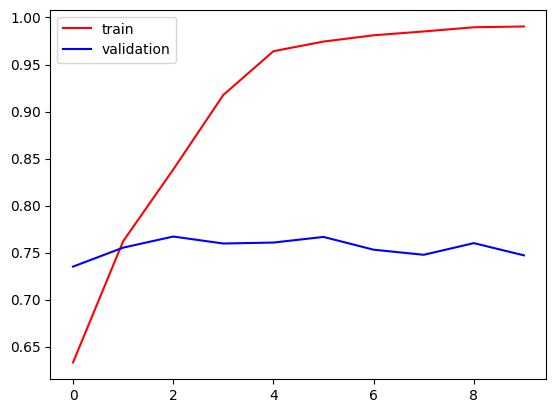

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

**After Batch Norm data:-**

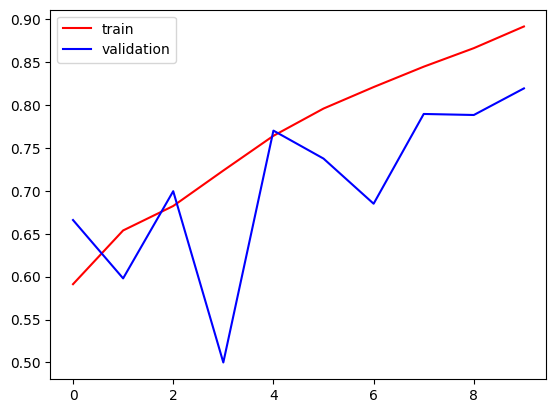

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

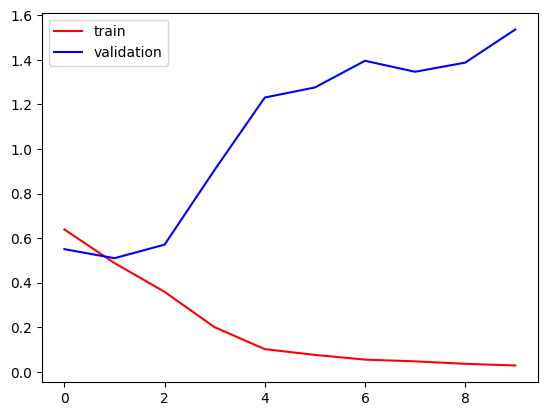

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

**After batch norm data:-**

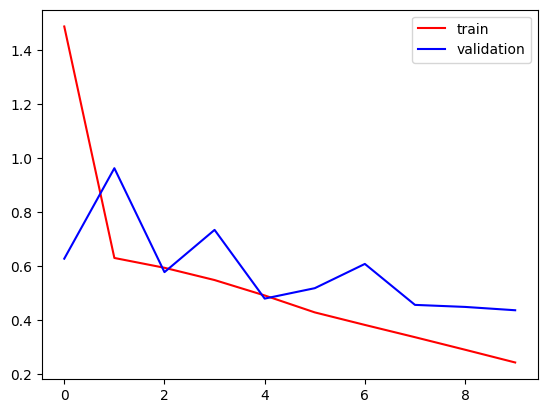

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

From both we can see that the training data results are far better than validation, showing clear signs of overfitting

Ways to reduce overfitting:
1. add more data
2. data augmentation -> by using existing data we create new
3. l1/l2 regularizer
4. dropout
5. batch norm
6. reduce complexity

**we use dropout and batch norm here**

In [ ]:
#for this in keras.layer add BatchNormalization & Dropout
#and in cnn model add batch norm code along with dropout between codes,(1)(2)

**now we test the model**

In [ ]:
#for image import computer vision lib as cv2
import cv2

In [ ]:
test_img=cv2.imread('/dog1.jpeg')

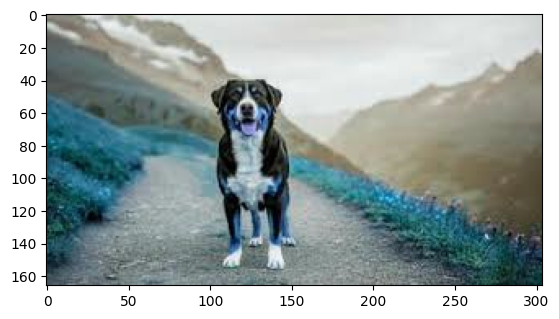

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(166, 304, 3)

In [ ]:
#need to reshape the image
test_img=cv2.resize(test_img,(256,256))

In [ ]:
test_input=test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[1.]], dtype=float32)